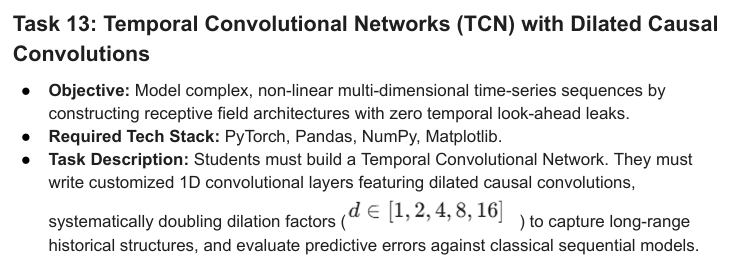

In [1]:
!pip install torch pandas numpy matplotlib

In [2]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

Device: cpu


In [4]:
np.random.seed(42)

time = np.arange(1000)

signal = (
    np.sin(time * 0.03)
    + 0.5 * np.sin(time * 0.08)
    + 0.001 * time
    + 0.1 * np.random.randn(1000)
)

df = pd.DataFrame({
    "time": time,
    "value": signal
})

print(df.head())

   time     value
0     0  0.049671
1     1  0.057126
2     2  0.206392
3     3  0.364033
4     4  0.257580


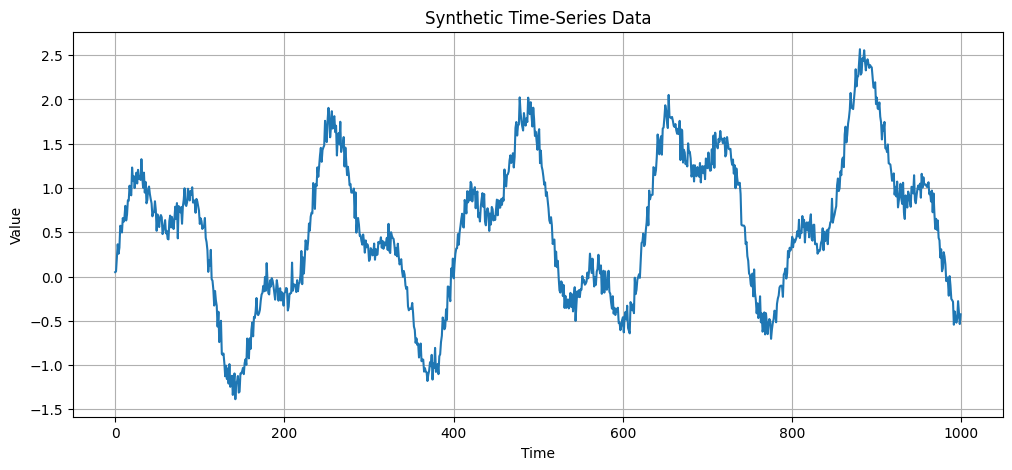

In [5]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["time"],
    df["value"]
)

plt.xlabel("Time")

plt.ylabel("Value")

plt.title(
    "Synthetic Time-Series Data"
)

plt.grid()

plt.show()

In [6]:
mean = df["value"].mean()

std = df["value"].std()

df["normalized"] = (
    df["value"] - mean
) / std

In [7]:
sequence_length = 50

X = []
y = []

values = df[
    "normalized"
].values

for i in range(
    len(values) - sequence_length
):

    X.append(
        values[
            i:i + sequence_length
        ]
    )

    y.append(
        values[
            i + sequence_length
        ]
    )

X = np.array(X)

y = np.array(y)

print(
    "X shape:",
    X.shape
)

print(
    "y shape:",
    y.shape
)

X shape: (950, 50)
y shape: (950,)


In [8]:
split = int(
    len(X) * 0.8
)

X_train = X[:split]

X_test = X[split:]

y_train = y[:split]

y_test = y[split:]

In [9]:
X_train = torch.tensor(
    X_train,
    dtype=torch.float32
).unsqueeze(1)

X_test = torch.tensor(
    X_test,
    dtype=torch.float32
).unsqueeze(1)

y_train = torch.tensor(
    y_train,
    dtype=torch.float32
).unsqueeze(1)

y_test = torch.tensor(
    y_test,
    dtype=torch.float32
).unsqueeze(1)

In [10]:
X_train = X_train.to(device)

X_test = X_test.to(device)

y_train = y_train.to(device)

y_test = y_test.to(device)

In [11]:
class CausalConv1D(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size,
        dilation
    ):

        super().__init__()

        self.padding = (
            kernel_size - 1
        ) * dilation

        self.conv = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size,
            padding=self.padding,
            dilation=dilation
        )

    def forward(self, x):

        x = self.conv(x)

        # Remove future-looking positions
        x = x[:, :, :-self.padding]

        return x

In [12]:
test_layer = CausalConv1D(
    1,
    16,
    kernel_size=3,
    dilation=1
)

test_output = test_layer(
    X_train[:4]
)

print(
    "Input:",
    X_train[:4].shape
)

print(
    "Output:",
    test_output.shape
)

Input: torch.Size([4, 1, 50])
Output: torch.Size([4, 16, 50])


In [13]:
class TCNBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size,
        dilation
    ):

        super().__init__()

        self.conv1 = CausalConv1D(
            in_channels,
            out_channels,
            kernel_size,
            dilation
        )

        self.conv2 = CausalConv1D(
            out_channels,
            out_channels,
            kernel_size,
            dilation
        )

        self.relu = nn.ReLU()

        self.dropout = nn.Dropout(
            0.1
        )

        if in_channels != out_channels:

            self.residual = nn.Conv1d(
                in_channels,
                out_channels,
                kernel_size=1
            )

        else:

            self.residual = nn.Identity()

    def forward(self, x):

        residual = self.residual(x)

        out = self.conv1(x)

        out = self.relu(out)

        out = self.dropout(out)

        out = self.conv2(out)

        out = self.relu(out)

        out = self.dropout(out)

        return out + residual

In [14]:
class TCN(nn.Module):

    def __init__(self):

        super().__init__()

        self.block1 = TCNBlock(
            1,
            32,
            kernel_size=3,
            dilation=1
        )

        self.block2 = TCNBlock(
            32,
            32,
            kernel_size=3,
            dilation=2
        )

        self.block3 = TCNBlock(
            32,
            32,
            kernel_size=3,
            dilation=4
        )

        self.block4 = TCNBlock(
            32,
            32,
            kernel_size=3,
            dilation=8
        )

        self.output = nn.Linear(
            32,
            1
        )

    def forward(self, x):

        x = self.block1(x)

        x = self.block2(x)

        x = self.block3(x)

        x = self.block4(x)

        # Take the final temporal position
        x = x[:, :, -1]

        return self.output(x)

In [15]:
model = TCN().to(device)

print(model)

TCN(
  (block1): TCNBlock(
    (conv1): CausalConv1D(
      (conv): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(2,))
    )
    (conv2): CausalConv1D(
      (conv): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(2,))
    )
    (relu): ReLU()
    (dropout): Dropout(p=0.1, inplace=False)
    (residual): Conv1d(1, 32, kernel_size=(1,), stride=(1,))
  )
  (block2): TCNBlock(
    (conv1): CausalConv1D(
      (conv): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
    )
    (conv2): CausalConv1D(
      (conv): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
    )
    (relu): ReLU()
    (dropout): Dropout(p=0.1, inplace=False)
    (residual): Identity()
  )
  (block3): TCNBlock(
    (conv1): CausalConv1D(
      (conv): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(4,))
    )
    (conv2): CausalConv1D(
      (conv): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(4,))
    )
    

In [16]:
prediction = model(
    X_train[:32]
)

print(
    "Prediction shape:",
    prediction.shape
)

Prediction shape: torch.Size([32, 1])


In [17]:
criterion = nn.MSELoss()

In [18]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [19]:
train_dataset = torch.utils.data.TensorDataset(
    X_train,
    y_train
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

In [20]:
epochs = 30

loss_history = []

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for batch_x, batch_y in train_loader:

        prediction = model(
            batch_x
        )

        loss = criterion(
            prediction,
            batch_y
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    average_loss = (
        total_loss /
        len(train_loader)
    )

    loss_history.append(
        average_loss
    )

    print(
        f"Epoch {epoch+1}/{epochs} "
        f"Loss: {average_loss:.5f}"
    )

Epoch 1/30 Loss: 0.31051
Epoch 2/30 Loss: 0.04738
Epoch 3/30 Loss: 0.03620
Epoch 4/30 Loss: 0.03686
Epoch 5/30 Loss: 0.03303
Epoch 6/30 Loss: 0.02939
Epoch 7/30 Loss: 0.03162
Epoch 8/30 Loss: 0.03170
Epoch 9/30 Loss: 0.02892
Epoch 10/30 Loss: 0.02831
Epoch 11/30 Loss: 0.02861
Epoch 12/30 Loss: 0.02704
Epoch 13/30 Loss: 0.02948
Epoch 14/30 Loss: 0.02457
Epoch 15/30 Loss: 0.02767
Epoch 16/30 Loss: 0.02560
Epoch 17/30 Loss: 0.02666
Epoch 18/30 Loss: 0.02692
Epoch 19/30 Loss: 0.02560
Epoch 20/30 Loss: 0.02571
Epoch 21/30 Loss: 0.02448
Epoch 22/30 Loss: 0.02478
Epoch 23/30 Loss: 0.02349
Epoch 24/30 Loss: 0.02420
Epoch 25/30 Loss: 0.02342
Epoch 26/30 Loss: 0.02270
Epoch 27/30 Loss: 0.02280
Epoch 28/30 Loss: 0.02475
Epoch 29/30 Loss: 0.02346
Epoch 30/30 Loss: 0.02306


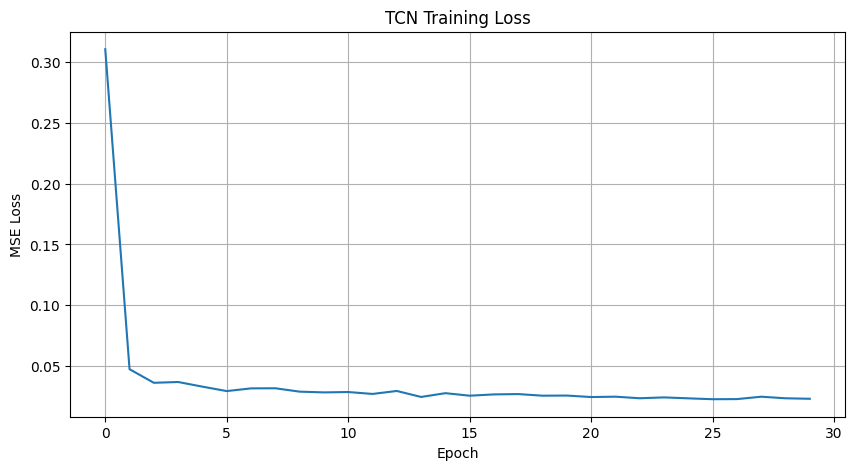

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(
    loss_history
)

plt.xlabel("Epoch")

plt.ylabel("MSE Loss")

plt.title(
    "TCN Training Loss"
)

plt.grid()

plt.show()

In [22]:
model.eval()

with torch.no_grad():

    predictions = model(
        X_test
    )

In [23]:
predictions = (
    predictions
    .cpu()
    .numpy()
    .flatten()
)

actual = (
    y_test
    .cpu()
    .numpy()
    .flatten()
)

In [24]:
mse = np.mean(
    (actual - predictions) ** 2
)

mae = np.mean(
    np.abs(
        actual - predictions
    )
)

print(
    "Test MSE:",
    mse
)

print(
    "Test MAE:",
    mae
)

Test MSE: 0.021951731
Test MAE: 0.11874461


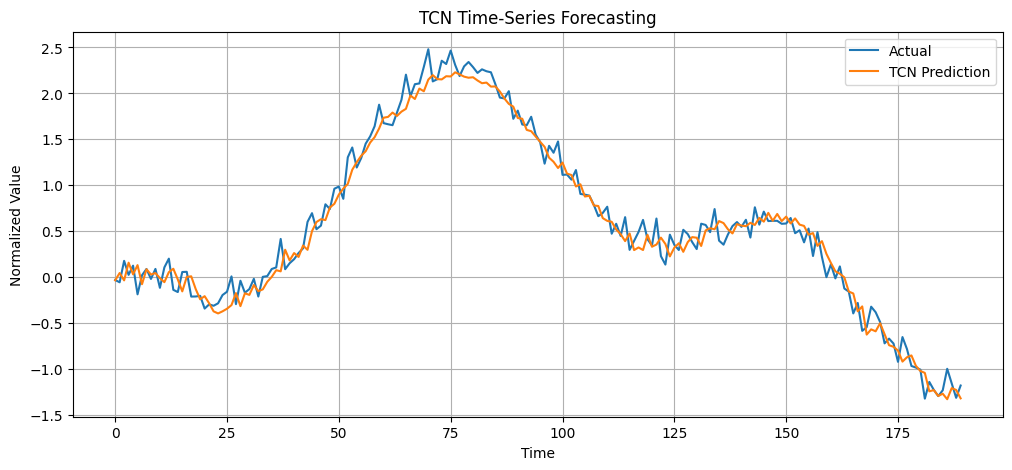

In [25]:
plt.figure(figsize=(12, 5))

plt.plot(
    actual,
    label="Actual"
)

plt.plot(
    predictions,
    label="TCN Prediction"
)

plt.xlabel("Time")

plt.ylabel("Normalized Value")

plt.title(
    "TCN Time-Series Forecasting"
)

plt.legend()

plt.grid()

plt.show()

In [26]:
actual_original = (
    actual * std + mean
)

predictions_original = (
    predictions * std + mean
)

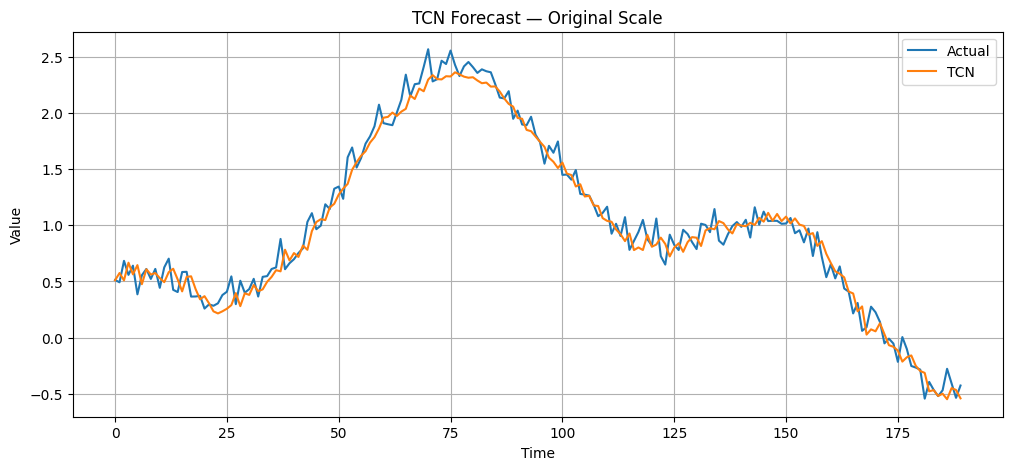

In [27]:
plt.figure(figsize=(12, 5))

plt.plot(
    actual_original,
    label="Actual"
)

plt.plot(
    predictions_original,
    label="TCN"
)

plt.xlabel("Time")

plt.ylabel("Value")

plt.title(
    "TCN Forecast — Original Scale"
)

plt.legend()

plt.grid()

plt.show()

In [28]:
baseline_predictions = (
    X_test[:, 0, -1]
    .cpu()
    .numpy()
)

In [29]:
baseline_mse = np.mean(
    (
        actual
        -
        baseline_predictions
    ) ** 2
)

baseline_mae = np.mean(
    np.abs(
        actual
        -
        baseline_predictions
    )
)

print(
    "Baseline MSE:",
    baseline_mse
)

print(
    "Baseline MAE:",
    baseline_mae
)

Baseline MSE: 0.028511006
Baseline MAE: 0.13636816


In [30]:
comparison = pd.DataFrame({
    "Model": [
        "Persistence Baseline",
        "TCN"
    ],

    "MSE": [
        baseline_mse,
        mse
    ],

    "MAE": [
        baseline_mae,
        mae
    ]
})

print(comparison)

                  Model       MSE       MAE
0  Persistence Baseline  0.028511  0.136368
1                   TCN  0.021952  0.118745


In [31]:
comparison

,Model,MSE,MAE
0,Persistence Baseline,0.028511,0.136368
1,TCN,0.021952,0.118745


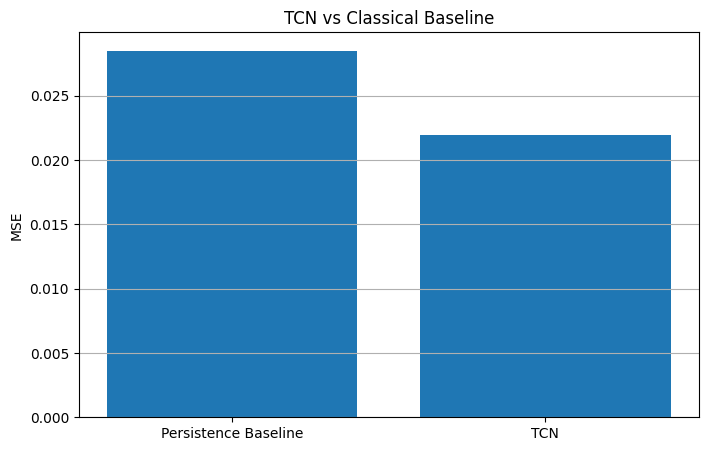

In [32]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["MSE"]
)

plt.ylabel("MSE")

plt.title(
    "TCN vs Classical Baseline"
)

plt.grid(
    axis="y"
)

plt.show()

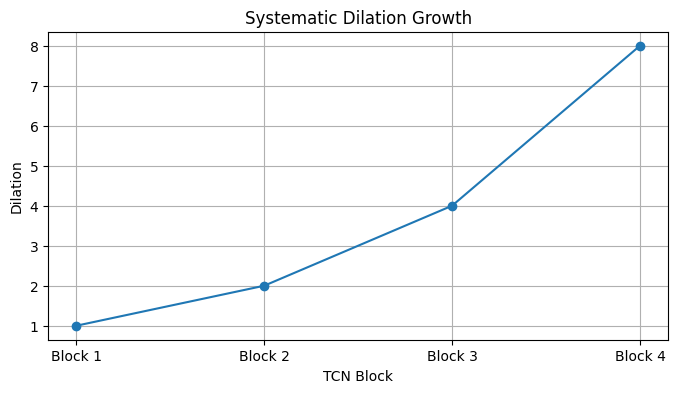

In [33]:
dilations = [1, 2, 4, 8]

plt.figure(figsize=(8, 4))

plt.plot(
    range(
        len(dilations)
    ),
    dilations,
    marker="o"
)

plt.xticks(
    range(len(dilations)),
    [
        "Block 1",
        "Block 2",
        "Block 3",
        "Block 4"
    ]
)

plt.xlabel("TCN Block")

plt.ylabel("Dilation")

plt.title(
    "Systematic Dilation Growth"
)

plt.grid()

plt.show()